In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Load the attached dataset

In [3]:
# Keep the dataset in the same folder as this notebook.
data = pd.read_csv("Breast_cancer_dataset.csv")

data.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
data.shape

(569, 33)

In [5]:
data.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [7]:
data.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


# Check missing values

In [9]:
data.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

# Remove unnecessary columns

In [11]:
data = data.drop(columns=["id", "Unnamed: 32"])

data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [12]:
data.shape

(569, 31)

**30 independent variables**
**1 target variable**

In [13]:
data["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

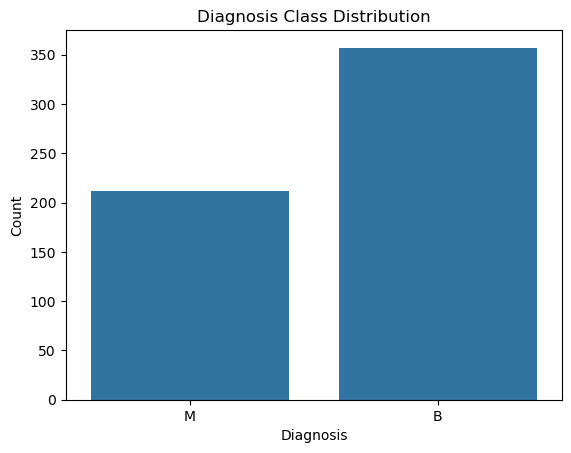

In [14]:
sns.countplot(x="diagnosis",data=data)

plt.title("Diagnosis Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

# Convert target variable

In [16]:
# Robust diagnosis conversion: accepts B/M and 0/1.
def normalize_diagnosis(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()
    mapping = {
        "b": 0, "benign": 0, "0": 0,
        "m": 1, "malignant": 1, "1": 1
    }
    return mapping.get(value, np.nan)

data["diagnosis"] = data["diagnosis"].apply(normalize_diagnosis)

if data["diagnosis"].isna().any():
    raise ValueError(
        "Invalid or missing diagnosis values. Expected B/M or 0/1."
    )

data["diagnosis"] = data["diagnosis"].astype(int)
data["diagnosis"].value_counts()


diagnosis
0    357
1    212
Name: count, dtype: int64

# Split independent and dependent variables

In [17]:
ind = data.drop(columns="diagnosis")

dep = data["diagnosis"]

ind.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Check feature dimensions

In [18]:
print("Number of instances:", ind.shape[0])
print("Number of features:", ind.shape[1])

Number of instances: 569
Number of features: 30


# Train-Test Split

In [20]:
from sklearn.model_selection import train_test_split

x, xt, y, yt = train_test_split(
    ind,
    dep,
    test_size=0.20,
    random_state=42,
    stratify=dep
)

print("Training data:", x.shape)
print("Testing data :", xt.shape)

Training data: (455, 30)
Testing data : (114, 30)


# Verify class proportions

In [21]:
print("Training class distribution:")
print(y.value_counts(normalize=True))

print("\nTesting class distribution:")
print(yt.value_counts(normalize=True))

Training class distribution:
diagnosis
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Testing class distribution:
diagnosis
0    0.631579
1    0.368421
Name: proportion, dtype: float64


# Feature Scaling

In [23]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()
x_mms = mms.fit_transform(x)
xt_mms = mms.transform(xt)

# Check scaled data

In [24]:
pd.DataFrame(x_mms, columns=x.columns).head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0.427801,0.457558,0.407090,0.277540,0.193775,0.145114,0.077296,0.165159,0.236364,0.142585,...,0.400569,0.582623,0.365506,0.237122,0.309912,0.124002,0.116534,0.342784,0.272620,0.193362
1,0.252686,0.090632,0.242278,0.135992,0.399346,0.154684,0.093416,0.183897,0.454040,0.197246,...,0.198150,0.096482,0.182081,0.089437,0.444628,0.096351,0.099201,0.322715,0.248768,0.083104
2,0.277770,0.394319,0.268399,0.157370,0.128853,0.195632,0.143533,0.092793,0.262626,0.230932,...,0.230167,0.399520,0.205289,0.113203,0.150895,0.161355,0.146805,0.192474,0.181944,0.173619
3,0.374793,0.433548,0.402944,0.229692,0.366340,0.623029,0.640347,0.482654,0.495455,0.397034,...,0.299538,0.414446,0.373475,0.159138,0.467080,0.661398,0.720367,0.850515,0.256456,0.396563
4,0.550381,0.356442,0.541151,0.403181,0.316087,0.267530,0.349110,0.384245,0.321717,0.143008,...,0.475987,0.406183,0.445690,0.299302,0.413590,0.178916,0.275240,0.512027,0.152967,0.125738


# Import all required models

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# Create the models

In [27]:
lr = LogisticRegression(max_iter=5000,random_state=42)

dt = DecisionTreeClassifier(max_depth=5,random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)

nb = GaussianNB()

rf = RandomForestClassifier(n_estimators=200,random_state=42,class_weight="balanced")

# Train all models

In [30]:
lr.fit(x_mms, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [31]:
dt.fit(x_mms, y)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [32]:
knn.fit(x_mms, y)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [33]:
nb.fit(x_mms, y)

,priors,None
,var_smoothing,1e-09


In [34]:
rf.fit(x_mms, y)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Generate predictions

In [40]:
lr_pred = lr.predict(xt_mms)
dt_pred = dt.predict(xt_mms)
knn_pred = knn.predict(xt_mms)
nb_pred = nb.predict(xt_mms)
rf_pred = rf.predict(xt_mms)

# Calculate the six required metrics: 
##### Accuracy
##### AUC
##### Precision
##### Recall
##### F1
##### MCC.

In [41]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

# Create evaluation function

In [42]:
def evaluate_model(model_name, model, x_test, y_test):

    y_pred = model.predict(x_test)

    y_prob = model.predict_proba(x_test)[:, 1]

    accuracy = accuracy_score(y_test,y_pred)

    auc = roc_auc_score(y_test,y_prob)

    precision = precision_score(y_test,y_pred,zero_division=0)

    recall = recall_score(y_test,y_pred,zero_division=0)

    f1 = f1_score(y_test,y_pred,zero_division=0)

    mcc = matthews_corrcoef(y_test,y_pred)

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"AUC       : {auc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"MCC       : {mcc:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Benign", "Malignant"],
            zero_division=0
        )
    )

    return {
        "ML Model Name": model_name,
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "MCC": mcc
    }

# Evaluate all models

In [45]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        lr,
        xt_mms,
        yt
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        dt,
        xt_mms,
        yt
    )
)

results.append(
    evaluate_model(
        "kNN",
        knn,
        xt_mms,
        yt
    )
)

results.append(
    evaluate_model(
        "Naive Bayes",
        nb,
        xt_mms,
        yt
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        rf,
        xt_mms,
        yt
    )
)



Logistic Regression
Accuracy  : 0.9737
AUC       : 0.9980
Precision : 1.0000
Recall    : 0.9286
F1 Score  : 0.9630
MCC       : 0.9442

Confusion Matrix:
[[72  0]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


Decision Tree
Accuracy  : 0.9211
AUC       : 0.9448
Precision : 0.9459
Recall    : 0.8333
F1 Score  : 0.8861
MCC       : 0.8299

Confusion Matrix:
[[70  2]
 [ 7 35]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.91      0.97      0.94        72
   Malignant       0.95      0.83      0.89        42

    accuracy                           0.92       114
   macro avg       0.93      0.90      0.91       114
weighted avg 

# Create the required comparison table

In [46]:
results_df = pd.DataFrame(results)
results_df = results_df.round(4)
results_df

,ML Model Name,Accuracy,AUC,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.9737,0.9980,1.0000,0.9286,0.9630,0.9442
1,Decision Tree,0.9211,0.9448,0.9459,0.8333,0.8861,0.8299
2,kNN,0.9561,0.9957,0.9744,0.9048,0.9383,0.9058
3,Naive Bayes,0.9211,0.9891,0.9231,0.8571,0.8889,0.8292
4,Random Forest,0.9649,0.9960,1.0000,0.9048,0.9500,0.9258


In [47]:
metric_columns = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1 Score",
    "MCC"
]

results_df["Average Score"] = results_df[
    metric_columns
].mean(axis=1)

results_df = results_df.sort_values(
    by="Average Score",
    ascending=False
)

results_df

,ML Model Name,Accuracy,AUC,Precision,Recall,F1 Score,MCC,Average Score
0,Logistic Regression,0.9737,0.9980,1.0000,0.9286,0.9630,0.9442,0.967917
4,Random Forest,0.9649,0.9960,1.0000,0.9048,0.9500,0.9258,0.956917
2,kNN,0.9561,0.9957,0.9744,0.9048,0.9383,0.9058,0.945850
3,Naive Bayes,0.9211,0.9891,0.9231,0.8571,0.8889,0.8292,0.901417
1,Decision Tree,0.9211,0.9448,0.9459,0.8333,0.8861,0.8299,0.893517


In [48]:
winner = results_df.iloc[0]["ML Model Name"]

print("Overall Winner:", winner)

Overall Winner: Logistic Regression


In [52]:
results_df.to_csv(
    "model_comparison.csv",
    index=False
)

# Create the required test_data.csv

In [62]:
test_data = xt.copy()
test_data["diagnosis"] = yt.to_numpy()

test_data.to_csv("test_data.csv", index=False)

print("test_data.csv created successfully.")
print("Diagnosis values:", sorted(test_data["diagnosis"].unique().tolist()))


test_data.csv created successfully.


# Save models

In [63]:
import os
import joblib

# Create a portable model folder beside the notebook.
output_folder = os.getcwd()
model_folder = os.path.join(output_folder, "model")
os.makedirs(model_folder, exist_ok=True)

# Save all trained models.
joblib.dump(lr, os.path.join(model_folder, "logistic_regression.pkl"))
joblib.dump(dt, os.path.join(model_folder, "decision_tree.pkl"))
joblib.dump(knn, os.path.join(model_folder, "knn.pkl"))
joblib.dump(nb, os.path.join(model_folder, "naive_bayes.pkl"))
joblib.dump(rf, os.path.join(model_folder, "random_forest.pkl"))

# IMPORTANT for deployment: save the fitted scaler used during training.
joblib.dump(mms, os.path.join(model_folder, "minmax_scaler.pkl"))

# IMPORTANT for deployment: save the exact feature order used by the models.
joblib.dump(ind.columns.tolist(), os.path.join(model_folder, "feature_columns.pkl"))

print("All models, scaler, and feature metadata saved successfully.")
print("Models location:", model_folder)


All models saved successfully.
Models location: C:\Users\sumit\Desktop\BITS_PLANI\ML\Assignment_2\model


# Confusion matrix visualization

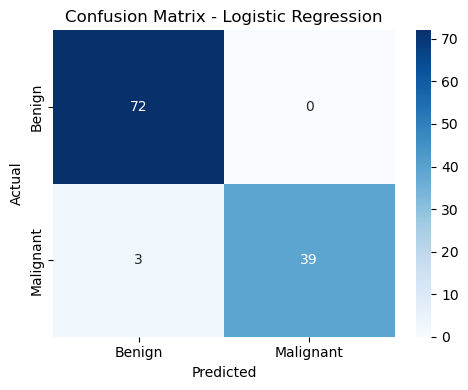

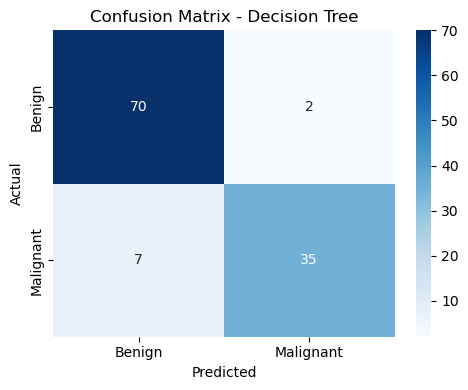

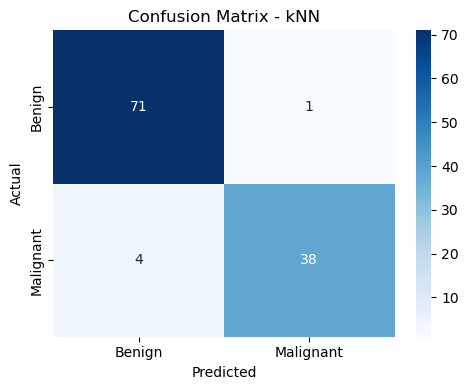

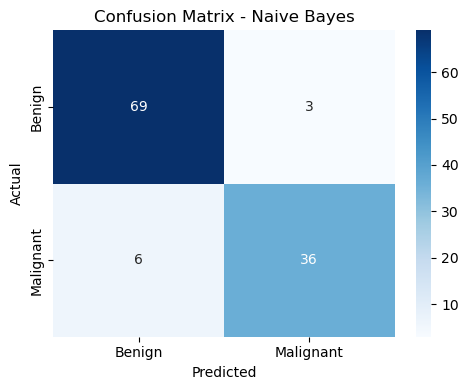

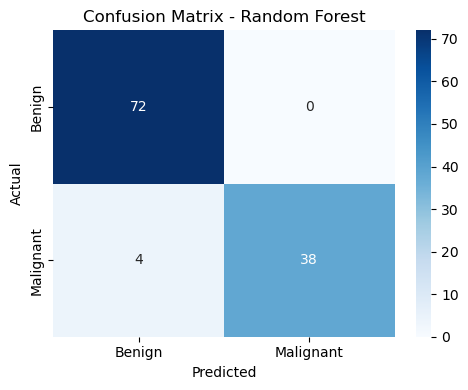

In [61]:
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "kNN": knn,
    "Naive Bayes": nb,
    "Random Forest": rf,
}

for model_name, model in models.items():

    y_pred = model.predict(xt_mms)

    cm = confusion_matrix(
        yt,
        y_pred
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Benign", "Malignant"],
        yticklabels=["Benign", "Malignant"]
    )

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()

# Deployment readiness

The deployment app accepts `diagnosis` values in either format:
- `B` = Benign, `M` = Malignant
- `0` = Benign, `1` = Malignant

For prediction-only CSV files, the `diagnosis` column is optional.
The deployment also uses the saved MinMaxScaler and exact training feature order.
